# Análise de Qualidade dos Dados Brutos - Amazon Products
## Identificação de Dados Problemáticos e Necessidade de Limpeza

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [2]:
df = pd.read_csv('data/amazon_products_sales_data_uncleaned.csv')
display(df.head(3))

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29


In [3]:
print(f"Total de registros: {len(df):,}")

# Tipo de dado de cada coluna
print(df.dtypes)

Total de registros: 42,675
title                       object
rating                      object
number_of_reviews           object
bought_in_last_month        object
current/discounted_price    object
price_on_variant            object
listed_price                object
is_best_seller              object
is_sponsored                object
is_couponed                 object
buy_box_availability        object
delivery_details            object
sustainability_badges       object
image_url                   object
product_url                 object
collected_at                object
dtype: object


## 1. Análise de Dados Faltantes

In [4]:
# Calculo dados faltantes por coluna
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Valores Vazios': (df == '').sum().values,
    'Total Problemático': df.isnull().sum().values + (df == '').sum().values,
    '% Problemático': ((df.isnull().sum().values + (df == '').sum().values) / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Total Problemático'] > 0].sort_values('Total Problemático', ascending=False)

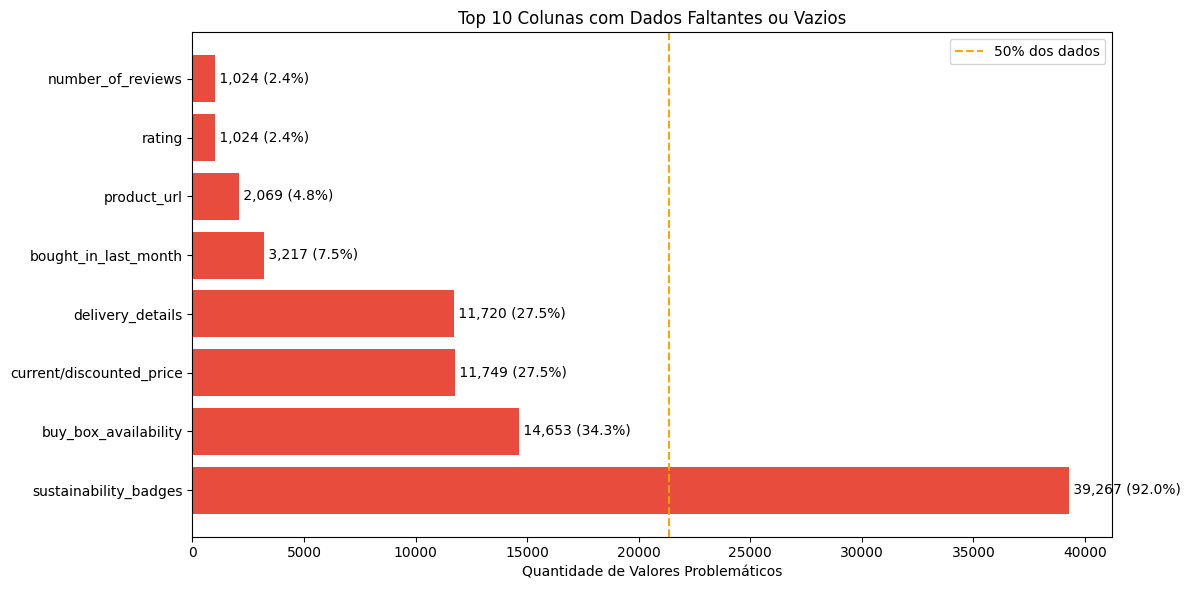

In [5]:
# Visualização de dados faltantes
fig, ax = plt.subplots(figsize=(12, 6))

colunas_problema = missing_data.head(10)['Coluna'].values
valores_problema = missing_data.head(10)['Total Problemático'].values

bars = ax.barh(colunas_problema, valores_problema, color='#e74c3c')
ax.set_xlabel('Quantidade de Valores Problemáticos')
ax.set_title('Top 10 Colunas com Dados Faltantes ou Vazios')
ax.axvline(len(df) * 0.5, color='orange', linestyle='--', label='50% dos dados')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f' {valores_problema[i]:,.0f} ({valores_problema[i]/len(df)*100:.1f}%)',
            ha='left', va='center')

ax.legend()
plt.tight_layout()
plt.show()

## 2. Análise de Preços Problemáticos

## 2.1. Visualização de Problemas de Preço


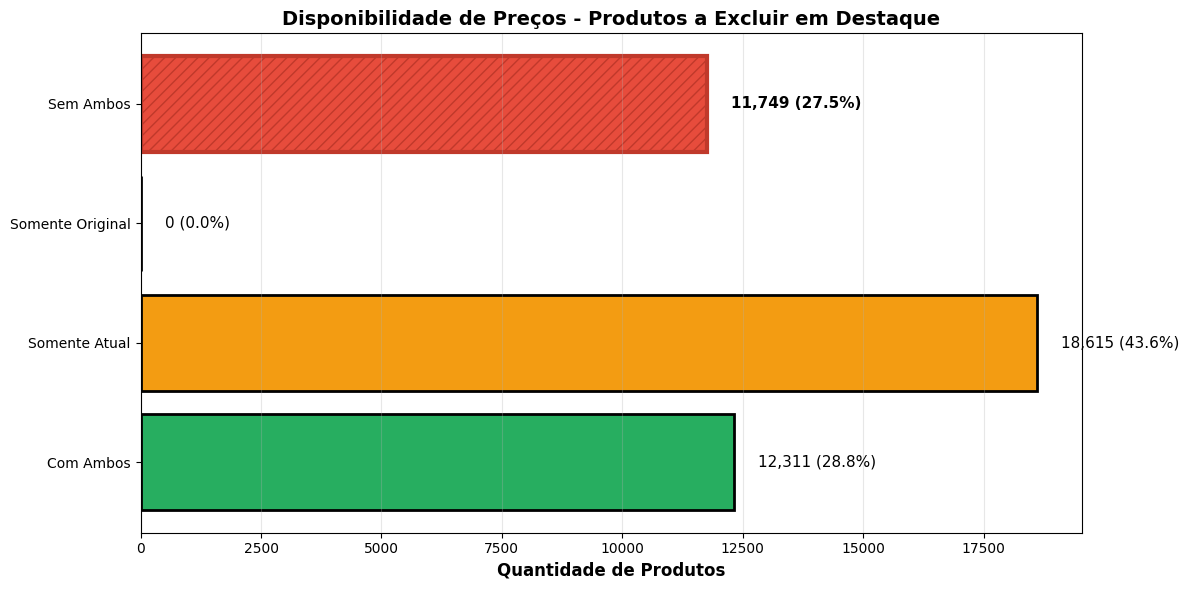


Produtos sem preços (a excluir): 11,749 (27.5%)
Produtos válidos: 30,926 (72.5%)


In [12]:
# Categorizar produtos
tem_atual = ~(df['current/discounted_price'].isnull() | (df['current/discounted_price'] == ''))
tem_original = ~(df['listed_price'].isnull() | (df['listed_price'] == '') | (df['listed_price'] == 'No Discount'))

categorias = ['Com Ambos', 'Somente Atual', 'Somente Original', 'Sem Ambos']
valores = [
    (tem_atual & tem_original).sum(),
    (tem_atual & ~tem_original).sum(),
    (~tem_atual & tem_original).sum(),
    (~tem_atual & ~tem_original).sum()
]

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
cores = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.barh(categorias, valores, color=cores, edgecolor='black', linewidth=2)

# Destacar "SEM PREÇOS"
bars[3].set_hatch('///')
bars[3].set_linewidth(3)
bars[3].set_edgecolor('#c0392b')

ax.set_xlabel('Quantidade de Produtos', fontsize=12, fontweight='bold')
ax.set_title('Disponibilidade de Preços - Produtos a Excluir em Destaque', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, valor) in enumerate(zip(bars, valores)):
    pct = (valor / len(df)) * 100
    label = f'{valor:,} ({pct:.1f}%)'
    if i == 3:  # SEM PREÇOS
        label = f'{label}'
    ax.text(valor + 500, bar.get_y() + bar.get_height()/2, label,
           va='center', fontsize=11, fontweight='bold' if i == 3 else 'normal')

plt.tight_layout()
plt.show()

print(f"\nProdutos sem preços (a excluir): {valores[3]:,} ({(valores[3]/len(df)*100):.1f}%)")
print(f"Produtos válidos: {sum(valores[:3]):,} ({(sum(valores[:3])/len(df)*100):.1f}%)")


## 3. Análise de Reviews Problemáticas

In [7]:
# Identificar problemas em reviews
sem_reviews = df['number_of_reviews'].isnull() | (df['number_of_reviews'] == '')
sem_rating = df['rating'].isnull() | (df['rating'] == '')


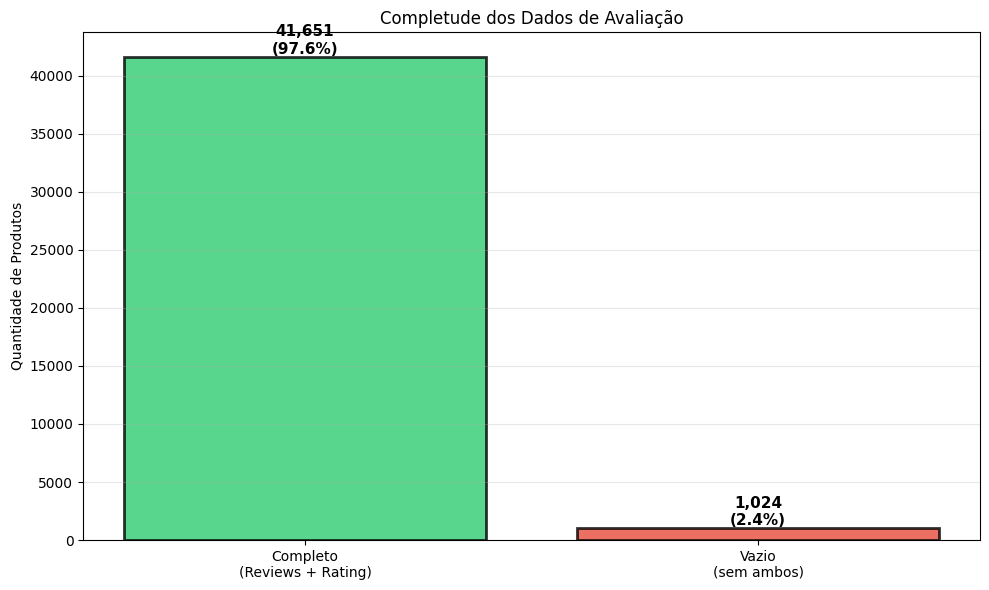

In [8]:
# Visualização de dados de reviews
fig, ax = plt.subplots(figsize=(10, 6))

categorias_rev = ['Completo\n(Reviews + Rating)', 'Vazio\n(sem ambos)']
valores_rev = [
    ((~sem_reviews) & (~sem_rating)).sum(),
    (sem_reviews & sem_rating).sum()
]
cores_rev = ['#2ecc71', '#e74c3c']

bars = ax.bar(categorias_rev, valores_rev, color=cores_rev, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Quantidade de Produtos')
ax.set_title('Completude dos Dados de Avaliação')
ax.grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{valores_rev[i]:,.0f}\n({valores_rev[i]/len(df)*100:.1f}%)',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()